In [79]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [80]:
# Create model class that inherits from nn.module
class Model(nn.Module):
    # Input layer (4 features of the flower)
    # --> Hidden layer 1 ( number of neurons )
    # --> Hidden layer 2 ( number of neurons )
    # Output ( 3 classes or species of the flower )

    def __init__(self, in_feature=4, h1=8, h2=9, out_features=3):
        super().__init__()
        self.fc1 = nn.Linear(in_feature, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x       

In [81]:
# Pick random seed for randomization 
torch.manual_seed(41)
# Create an instant of model 
model = Model()

In [82]:
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline 

In [83]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [84]:
my_df['variety'] = my_df['variety'].replace('Setosa',0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor',1.0)
my_df['variety'] = my_df['variety'].replace('Virginica',2.0)
my_df

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14520\3971052351.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica',2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [85]:
X = my_df.drop('variety', axis=1)
y = my_df['variety']

In [86]:
X = X.values
y = y.values

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=41
)

In [88]:
# Convert X label into float tensor 
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [89]:
# Convert X label into long tensor 
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [90]:
# Set the criterion of the model to measure the error, how far off the prediction from the data 
criterion = nn.CrossEntropyLoss()
# choose adam optimizer 
# lr = learning rate ( if error doesn't go down after bunch of iterations (epochs), lower the learning rate in this situation )
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [91]:
# Train the model 
# Epoch? (one run thru the training data in out network)
epochs = 100
losses = []

for i in range(epochs):
    # move forward and get prediction 
    y_pred = model.forward(X_train) # get prediction result 

    # Measure the loss/error, gonna be hight at first 
    loss = criterion(y_pred, y_train)

    # Keep track of the losses 

    losses.append(loss.detach().numpy())

    if i % 10 == 0 :
        print(f'epoch: {i} and loss: {loss}')


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()    

epoch: 0 and loss: 1.125203251838684
epoch: 10 and loss: 1.0097211599349976
epoch: 20 and loss: 0.8162347078323364
epoch: 30 and loss: 0.585993230342865
epoch: 40 and loss: 0.4003389775753021
epoch: 50 and loss: 0.26794713735580444
epoch: 60 and loss: 0.1796349585056305
epoch: 70 and loss: 0.12165625393390656
epoch: 80 and loss: 0.08606519550085068
epoch: 90 and loss: 0.06522615998983383


Text(0.5, 0, 'Epochs')

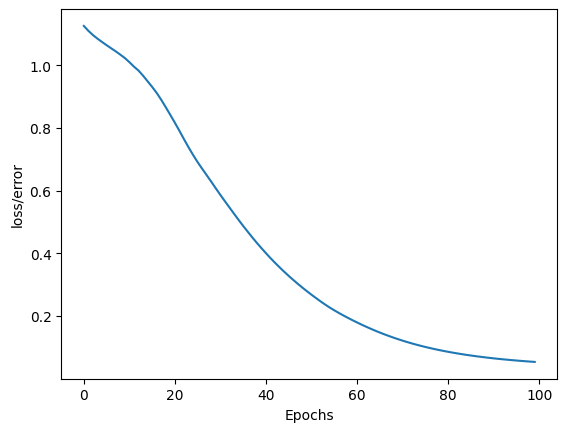

In [92]:
plt.plot(range(epochs), losses)
plt.ylabel('loss/error')
plt.xlabel('Epochs')

In [95]:

with torch.no_grad():
    y_eval =  model.forward(X_test)
    loss = criterion(y_eval, y_test)   

In [96]:
loss

tensor(0.1315)

In [103]:
correct = 0 
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)


        if y_test[i] == 0:
            x = "Setosa"
        elif y_test[i] == 1:
            x = "Versicolor"
        else : x = "Virginica"                

        print(f'{i+1}.) {str(y_val )} \t {x} \t {y_val.argmax().item()}')

        # Correct or not 
        if y_val.argmax().item() == y_test[i]:
            correct += 1
print(f'there are {correct} correct')

1.) tensor([-5.8771,  4.4629,  6.5155]) 	 Virginica 	 2
2.) tensor([-7.5451,  4.1668,  9.7293]) 	 Virginica 	 2
3.) tensor([-8.4517,  5.1275, 10.2015]) 	 Virginica 	 2
4.) tensor([-4.3411,  5.6280,  2.5636]) 	 Versicolor 	 1
5.) tensor([-7.1838,  4.8757,  8.3023]) 	 Virginica 	 2
6.) tensor([-3.3940,  5.3421,  1.2802]) 	 Versicolor 	 1
7.) tensor([-5.9240,  4.9826,  6.0025]) 	 Virginica 	 2
8.) tensor([-4.2895,  5.7016,  2.3920]) 	 Versicolor 	 1
9.) tensor([-6.5369,  4.9261,  7.1291]) 	 Virginica 	 2
10.) tensor([-8.0526,  4.4129, 10.3325]) 	 Virginica 	 2
11.) tensor([-5.6775,  4.9505,  5.6248]) 	 Virginica 	 2
12.) tensor([ 4.5748, -2.2579, -2.8925]) 	 Setosa 	 0
13.) tensor([ 4.2646, -2.0055, -2.7342]) 	 Setosa 	 0
14.) tensor([-2.1081,  4.0482,  0.5803]) 	 Versicolor 	 1
15.) tensor([ 3.4608, -1.2147, -2.3488]) 	 Setosa 	 0
16.) tensor([-5.4739,  5.1174,  5.0966]) 	 Virginica 	 1
17.) tensor([ 4.0637, -1.8045, -2.6504]) 	 Setosa 	 0
18.) tensor([-5.8090,  4.6057,  6.2494]) 	 Versi